# Havayolu Yolcu Memnuniyeti — Model Karşılaştırması ve SHAP Tabanlı Öznitelik Seçimi

Bu notebook iki aşamalıdır:
- **Bölüm 1:** Tüm özniteliklerle 8 modelin 5-katlı çapraz doğrulama karşılaştırması (baseline)
- **Bölüm 2:** SHAP tabanlı öznitelik seçimi ve seçim sonrası model karşılaştırması

In [3]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', 'xgboost', '-q'])
print('Kurulum tamamlandı.')

Kurulum tamamlandı.


In [4]:
# ============================================================
# HÜCRE 1 — Kütüphaneler ve yardımcı fonksiyonlar
# ============================================================
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import shap

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC, SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, confusion_matrix,
    ConfusionMatrixDisplay, make_scorer,
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
shap.initjs()

# --- Yardımcı fonksiyonlar ---
def find_existing_path(filename, required=True):
    candidates = [
        Path.cwd() / filename,
        Path.cwd() / "data" / filename,
        Path.cwd().parent / "data" / filename,
        Path("/mnt/data") / filename,
    ]
    for c in candidates:
        if c.exists():
            return c
    if required:
        raise FileNotFoundError(f"'{filename}' bulunamadı.")
    return None

def resolve_output_dir():
    for c in [Path.cwd()/"outputs", Path.cwd().parent/"outputs", Path("/mnt/data")/"outputs"]:
        if c.exists():
            (c/"figures").mkdir(exist_ok=True)
            (c/"tables").mkdir(exist_ok=True)
            return c
    out = Path.cwd() / "outputs"
    (out/"figures").mkdir(parents=True, exist_ok=True)
    (out/"tables").mkdir(parents=True, exist_ok=True)
    return out

def make_ohe(dense=False):
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=not dense)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=not dense)

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0.0

TRAIN_PATH  = find_existing_path("train.csv")
TEST_PATH   = find_existing_path("test.csv", required=False)
OUTPUT_DIR  = resolve_output_dir()
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR  = OUTPUT_DIR / "tables"

print("Train yolu    :", TRAIN_PATH)
print("Test yolu     :", TEST_PATH or "Yok")
print("Çıktı klasörü :", OUTPUT_DIR.resolve())


Train yolu    : c:\ML\MemnuniyetTahmini\data\train.csv
Test yolu     : c:\ML\MemnuniyetTahmini\data\test.csv
Çıktı klasörü : C:\ML\MemnuniyetTahmini\outputs


In [5]:
# ============================================================
# HÜCRE 2 — Veri yükleme ve ön işleme
# ============================================================
def prepare_dataset(df):
    df = df.copy()
    df = df.drop(columns=["Unnamed: 0", "id"], errors="ignore")
    if "Arrival Delay in Minutes" in df.columns:
        df["Arrival Delay in Minutes"] = df["Arrival Delay in Minutes"].fillna(
            df["Arrival Delay in Minutes"].median()
        )
    if "satisfaction" not in df.columns:
        raise ValueError("'satisfaction' sütunu bulunamadı.")
    df["satisfaction"] = df["satisfaction"].map({
        "neutral or dissatisfied": 0, "satisfied": 1
    })
    X = df.drop("satisfaction", axis=1)
    y = df["satisfaction"]
    return X, y

train_df = pd.read_csv(TRAIN_PATH)
X, y = prepare_dataset(train_df)

categorical_features = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
numeric_features     = X.select_dtypes(exclude=["object", "string", "category"]).columns.tolist()

print("Train X boyutu:", X.shape)
print("Kategorik sütunlar:", categorical_features)
print("Sayısal sütunlar  :", numeric_features)

# Sınıf dağılımı
counts = train_df["satisfaction"].value_counts()
pcts   = train_df["satisfaction"].value_counts(normalize=True) * 100
for label in counts.index:
    print(f"  {label}: {counts[label]} ({pcts[label]:.2f}%)")

if TEST_PATH is not None:
    test_df = pd.read_csv(TEST_PATH)
    X_external, y_external = prepare_dataset(test_df)
    X_external = X_external[X.columns]
    print("External X boyutu:", X_external.shape)
else:
    X_external, y_external = None, None
    print("test.csv bulunamadı — external test atlanacak.")


Train X boyutu: (103904, 22)
Kategorik sütunlar: ['Gender', 'Customer Type', 'Type of Travel', 'Class']
Sayısal sütunlar  : ['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
  neutral or dissatisfied: 58879 (56.67%)
  satisfied: 45025 (43.33%)
External X boyutu: (25976, 22)


## Bölüm 1 — Baseline: Tüm Özniteliklerle 8 Model

In [6]:
# ============================================================
# HÜCRE 3 — Preprocessor tanımları (baseline)
# ============================================================
preprocessor_sparse = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", make_ohe(dense=False), categorical_features),
])
preprocessor_dense = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", make_ohe(dense=True), categorical_features),
])
print("Preprocessor'lar hazır.")


Preprocessor'lar hazır.


In [7]:
# ============================================================
# HÜCRE 4 — Model parametreleri (baseline)
# ============================================================
models = {
    "kNN": Pipeline([
        ("preprocessor", preprocessor_sparse),
        ("classifier", KNeighborsClassifier(n_neighbors=5))
    ]),
    "Naive Bayes": Pipeline([
        ("preprocessor", preprocessor_dense),
        ("classifier", GaussianNB())
    ]),
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor_sparse),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "LSVM": Pipeline([
        ("preprocessor", preprocessor_sparse),
        ("classifier", LinearSVC(random_state=42, max_iter=5000))
    ]),
    "RBF SVM": Pipeline([
        ("preprocessor", preprocessor_sparse),
        ("classifier", SVC(kernel="rbf", random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor_sparse),
        ("classifier", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
    ]),
    "MLP": Pipeline([
        ("preprocessor", preprocessor_sparse),
        ("classifier", MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42))
    ]),
    "XGBoost": Pipeline([
        ("preprocessor", preprocessor_sparse),
        ("classifier", XGBClassifier(
            n_estimators=100, random_state=42,
            eval_metric="logloss", verbosity=0, n_jobs=-1
        ))
    ]),
}

# Model parametreleri tablosu
selected_params = {
    "kNN":                 ["n_neighbors"],
    "Naive Bayes":         [],
    "Logistic Regression": ["max_iter", "random_state"],
    "LSVM":                ["max_iter", "random_state"],
    "RBF SVM":             ["kernel"],
    "Random Forest":       ["n_estimators", "random_state", "n_jobs"],
    "MLP":                 ["hidden_layer_sizes", "max_iter", "random_state"],
    "XGBoost":             ["n_estimators", "random_state", "eval_metric", "verbosity", "n_jobs"],
}
rows = []
for mn, pipeline in models.items():
    clf = pipeline.named_steps["classifier"]
    params = clf.get_params()
    keys = selected_params.get(mn, [])
    short_params = ", ".join(f"{k}={params[k]!r}" for k in keys if k in params) or "Default"
    rows.append({"Model": mn, "Sınıflandırıcı": clf.__class__.__name__, "Parametreler": short_params})
display(pd.DataFrame(rows))


,Model,Sınıflandırıcı,Parametreler
0,kNN,KNeighborsClassifier,n_neighbors=5
1,Naive Bayes,GaussianNB,Default
2,Logistic Regression,LogisticRegression,"max_iter=1000, random_state=42"
3,LSVM,LinearSVC,"max_iter=5000, random_state=42"
4,RBF SVM,SVC,kernel='rbf'
5,Random Forest,RandomForestClassifier,"n_estimators=100, random_state=42, n_jobs=-1"
6,MLP,MLPClassifier,"hidden_layer_sizes=(100,), max_iter=300, rando..."
7,XGBoost,XGBClassifier,"n_estimators=100, random_state=42, eval_metric..."


In [8]:
# ============================================================
# HÜCRE 5 — 5-Katlı Katmanlı Çapraz Doğrulama (Baseline)
# ============================================================
scoring = {
    "accuracy":    "accuracy",
    "precision":   make_scorer(precision_score, zero_division=0),
    "recall":      make_scorer(recall_score, zero_division=0),
    "f1":          make_scorer(f1_score, zero_division=0),
    "specificity": make_scorer(specificity_score),
    "mcc":         make_scorer(matthews_corrcoef),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_results     = []
cv_summary       = []
cv_scores_by_model = {}

for model_name, model in models.items():
    print(f"===== {model_name} =====")
    scores = cross_validate(
        model, X, y, cv=cv, scoring=scoring,
        n_jobs=1, return_train_score=False, error_score="raise"
    )
    cv_scores_by_model[model_name] = scores
    for i in range(5):
        fold_results.append({
            "Model": model_name, "Fold": i + 1,
            "Accuracy":    scores["test_accuracy"][i],
            "Precision":   scores["test_precision"][i],
            "Recall":      scores["test_recall"][i],
            "F1":          scores["test_f1"][i],
            "Specificity": scores["test_specificity"][i],
            "MCC":         scores["test_mcc"][i],
        })
    cv_summary.append({
        "Model":              model_name,
        "CV Accuracy Mean":   scores["test_accuracy"].mean(),
        "CV Accuracy Std":    scores["test_accuracy"].std(),
        "CV Precision Mean":  scores["test_precision"].mean(),
        "CV Recall Mean":     scores["test_recall"].mean(),
        "CV F1 Mean":         scores["test_f1"].mean(),
        "CV Specificity Mean":scores["test_specificity"].mean(),
        "CV MCC Mean":        scores["test_mcc"].mean(),
    })

fold_results_df = pd.DataFrame(fold_results)
cv_results_df = pd.DataFrame(cv_summary).sort_values(
    by=["CV Accuracy Mean", "CV F1 Mean", "CV MCC Mean"], ascending=False
).reset_index(drop=True)

print("\n=== Her Foldun Sonuçları ===")
display(fold_results_df)
print("\n=== Ortalama CV Sonuçları ===")
display(cv_results_df)

fold_results_df.to_csv(TABLES_DIR / "fold_results.csv", index=False)
cv_results_df.to_csv(TABLES_DIR / "cross_validation_results.csv", index=False)


===== kNN =====
===== Naive Bayes =====
===== Logistic Regression =====
===== LSVM =====
===== RBF SVM =====
===== Random Forest =====
===== MLP =====
===== XGBoost =====

=== Her Foldun Sonuçları ===


,Model,Fold,Accuracy,Precision,Recall,F1,Specificity,MCC
0,kNN,1,0.924883,0.942148,0.880733,0.910406,0.958645,0.847289
1,kNN,2,0.926616,0.945663,0.881288,0.912341,0.961277,0.850929
2,kNN,3,0.929407,0.945614,0.888173,0.915994,0.960938,0.856472
3,kNN,4,0.929022,0.943881,0.889062,0.915652,0.959579,0.855619
4,kNN,5,0.925168,0.940411,0.883287,0.910955,0.957197,0.847769
5,Naive Bayes,1,0.848949,0.836894,0.809106,0.822766,0.879416,0.691521
6,Naive Bayes,2,0.846158,0.829925,0.811216,0.820464,0.872877,0.686049
7,Naive Bayes,3,0.850537,0.831964,0.820877,0.826383,0.873217,0.695232
8,Naive Bayes,4,0.852510,0.831621,0.827096,0.829352,0.871943,0.699495
9,Naive Bayes,5,0.843936,0.827089,0.808995,0.817942,0.870658,0.681534



=== Ortalama CV Sonuçları ===


,Model,CV Accuracy Mean,CV Accuracy Std,CV Precision Mean,CV Recall Mean,CV F1 Mean,CV Specificity Mean,CV MCC Mean
0,XGBoost,0.962860,0.001563,0.970255,0.943209,0.956540,0.977887,0.924409
1,Random Forest,0.962600,0.001045,0.972356,0.940433,0.956124,0.979551,0.923946
2,MLP,0.957028,0.002429,0.955857,0.944564,0.950135,0.966558,0.912495
3,RBF SVM,0.952523,0.001118,0.957443,0.931860,0.944477,0.968325,0.903278
4,kNN,0.927019,0.001890,0.943543,0.884509,0.913069,0.959527,0.851616
5,Logistic Regression,0.875212,0.002185,0.870817,0.836091,0.853086,0.905127,0.745194
6,LSVM,0.874394,0.002684,0.870951,0.833692,0.851902,0.905518,0.743499
7,Naive Bayes,0.848418,0.003056,0.831499,0.815458,0.823381,0.873622,0.690766


In [9]:
# ============================================================
# HÜCRE 6 — Her model için fold bazlı detay
# ============================================================
for model_name in models.keys():
    scores = cv_scores_by_model[model_name]
    print(f"\n--- {model_name} ---")
    print("Accuracy   :", scores["test_accuracy"].round(8))
    print("Precision  :", scores["test_precision"].round(8))
    print("Recall     :", scores["test_recall"].round(8))
    print("F1         :", scores["test_f1"].round(8))
    print("Specificity:", scores["test_specificity"].round(8))
    print("MCC        :", scores["test_mcc"].round(8))



--- kNN ---
Accuracy   : [0.92488331 0.92661566 0.92940667 0.9290217  0.92516843]
Precision  : [0.94214778 0.94566254 0.94561362 0.94388116 0.94041144]
Recall     : [0.88073293 0.88128817 0.88817324 0.88906163 0.88328706]
F1         : [0.91040579 0.91234121 0.91599382 0.91565163 0.91095459]
Specificity: [0.9586447  0.96127717 0.9609375  0.9595788  0.95719745]
MCC        : [0.84728936 0.85092932 0.85647172 0.85561905 0.84776911]

--- Naive Bayes ---
Accuracy   : [0.84894856 0.84615755 0.85053655 0.8525095  0.84393648]
Precision  : [0.8368941  0.82992502 0.83196398 0.83162126 0.82708901]
Recall     : [0.80910605 0.81121599 0.82087729 0.82709606 0.808995  ]
F1         : [0.82276551 0.82046386 0.82638345 0.82935249 0.81794195]
Specificity: [0.87941576 0.87287704 0.87321671 0.87194293 0.87065817]
MCC        : [0.6915213  0.68604872 0.69523216 0.69949488 0.68153421]

--- Logistic Regression ---
Accuracy   : [0.87758048 0.87175786 0.87690679 0.87618498 0.87362849]
Precision  : [0.87858901 0.

=== Genel Sonuç Tablosu (Baseline) ===


,Model,Accuracy,Precision,Recall,F1,Specificity,MCC
0,XGBoost,0.9629,0.9703,0.9432,0.9565,0.9779,0.9244
1,Random Forest,0.9626,0.9724,0.9404,0.9561,0.9796,0.9239
2,MLP,0.9570,0.9559,0.9446,0.9501,0.9666,0.9125
3,RBF SVM,0.9525,0.9574,0.9319,0.9445,0.9683,0.9033
4,kNN,0.9270,0.9435,0.8845,0.9131,0.9595,0.8516
5,Logistic Regression,0.8752,0.8708,0.8361,0.8531,0.9051,0.7452
6,LSVM,0.8744,0.8710,0.8337,0.8519,0.9055,0.7435
7,Naive Bayes,0.8484,0.8315,0.8155,0.8234,0.8736,0.6908


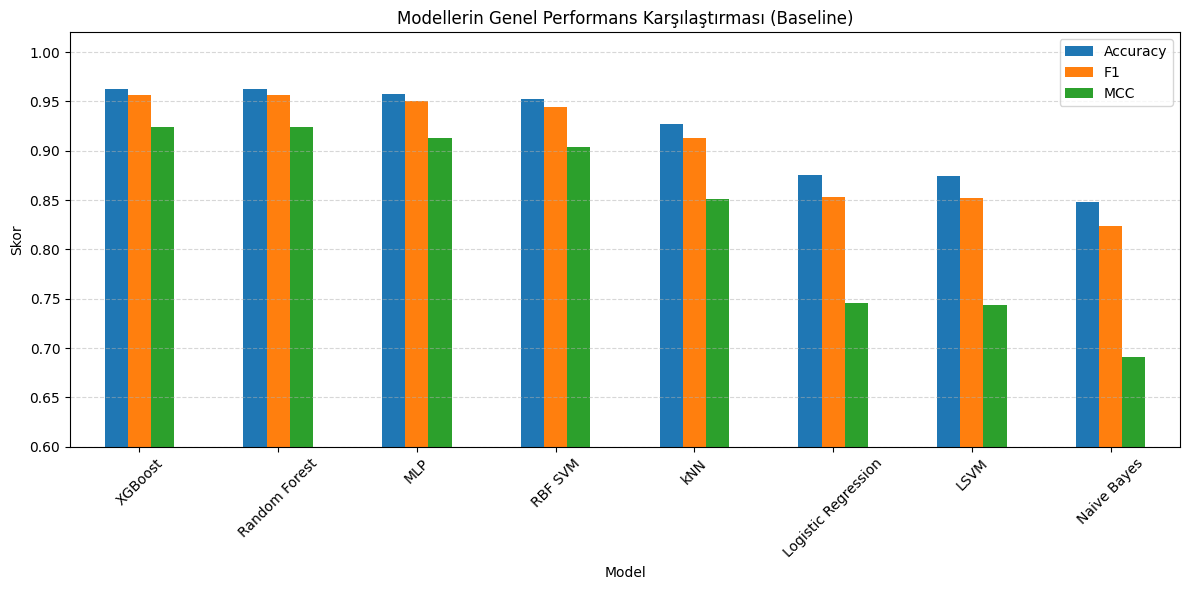

Grafik kaydedildi.


In [10]:
# ============================================================
# HÜCRE 7 — Özet tablo ve grafik (Baseline)
# ============================================================
summary_table = cv_results_df[[
    "Model", "CV Accuracy Mean", "CV Precision Mean",
    "CV Recall Mean", "CV F1 Mean", "CV Specificity Mean", "CV MCC Mean"
]].copy()
summary_table.columns = ["Model", "Accuracy", "Precision", "Recall", "F1", "Specificity", "MCC"]
summary_table = summary_table.round(4).sort_values("Accuracy", ascending=False).reset_index(drop=True)

print("=== Genel Sonuç Tablosu (Baseline) ===")
display(summary_table)
summary_table.to_csv(TABLES_DIR / "summary_table_baseline.csv", index=False)

plot_table = summary_table.set_index("Model")[["Accuracy", "F1", "MCC"]]
fig, ax = plt.subplots(figsize=(12, 6))
plot_table.plot(kind="bar", ax=ax, rot=45)
ax.set_ylabel("Skor")
ax.set_title("Modellerin Genel Performans Karşılaştırması (Baseline)")
ax.set_ylim(0.6, 1.02)
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "general_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
print("Grafik kaydedildi.")


In [11]:
# ============================================================
# HÜCRE 8 — Bağımsız test kümesi (Baseline)
# ============================================================
if X_external is not None:
    external_results = []
    trained_models   = {}
    for model_name, model in models.items():
        print(f"External test: {model_name}")
        model.fit(X, y)
        trained_models[model_name] = model
        y_pred = model.predict(X_external)
        external_results.append({
            "Model":              model_name,
            "External Accuracy":  accuracy_score(y_external, y_pred),
            "External Precision": precision_score(y_external, y_pred, zero_division=0),
            "External Recall":    recall_score(y_external, y_pred, zero_division=0),
            "External F1":        f1_score(y_external, y_pred, zero_division=0),
            "External Specificity": specificity_score(y_external, y_pred),
            "External MCC":       matthews_corrcoef(y_external, y_pred),
        })
    external_results_df = pd.DataFrame(external_results).sort_values(
        "External Accuracy", ascending=False
    ).reset_index(drop=True)
    print("\n=== External Test Sonuçları (Baseline) ===")
    display(external_results_df)
    external_results_df.to_csv(TABLES_DIR / "external_test_results.csv", index=False)
else:
    trained_models      = {}
    external_results_df = None
    print("test.csv bulunamadı.")


External test: kNN
External test: Naive Bayes
External test: Logistic Regression
External test: LSVM
External test: RBF SVM
External test: Random Forest
External test: MLP
External test: XGBoost

=== External Test Sonuçları (Baseline) ===


,Model,External Accuracy,External Precision,External Recall,External F1,External Specificity,External MCC
0,XGBoost,0.963428,0.971578,0.944313,0.957751,0.978385,0.925814
1,Random Forest,0.963428,0.972858,0.942997,0.957695,0.979414,0.925850
2,MLP,0.959655,0.963809,0.943524,0.953558,0.972277,0.918065
3,RBF SVM,0.954188,0.958352,0.936333,0.947214,0.968160,0.906950
4,kNN,0.929242,0.944677,0.890994,0.917050,0.959171,0.856565
5,Logistic Regression,0.871843,0.869350,0.833289,0.850938,0.902011,0.739142
6,LSVM,0.870765,0.869354,0.830396,0.849428,0.902354,0.736932
7,Naive Bayes,0.844125,0.829185,0.812242,0.820626,0.869073,0.682947


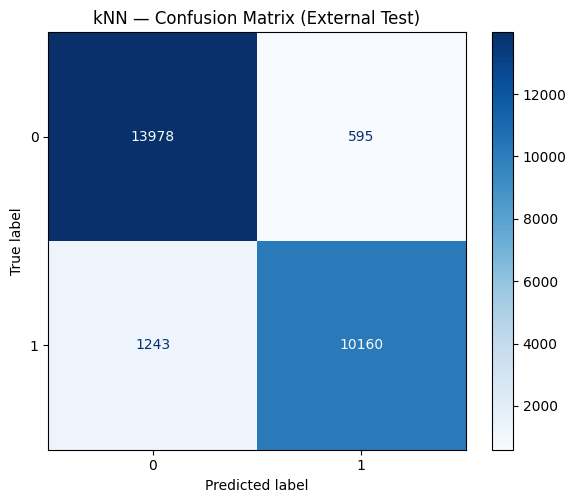

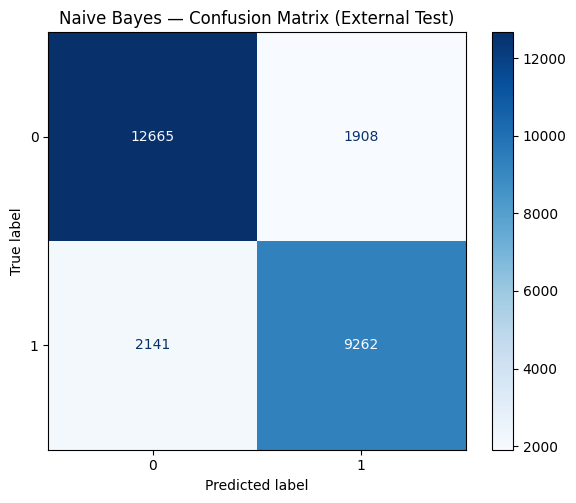

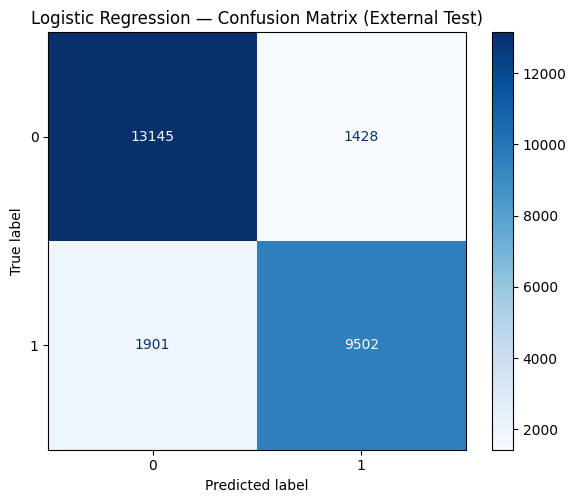

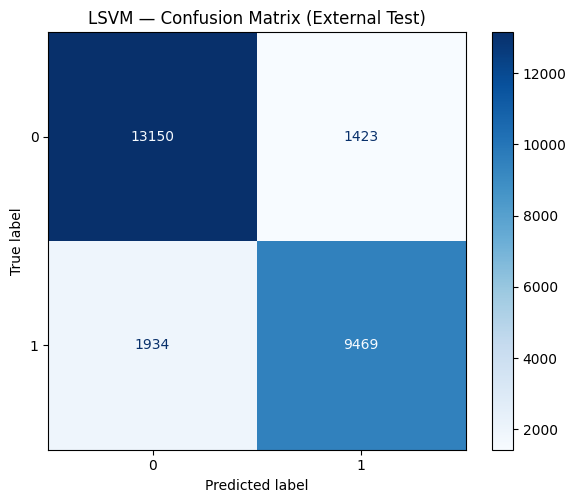

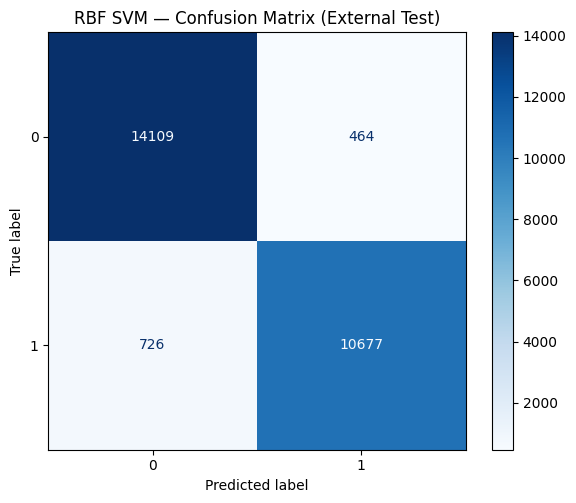

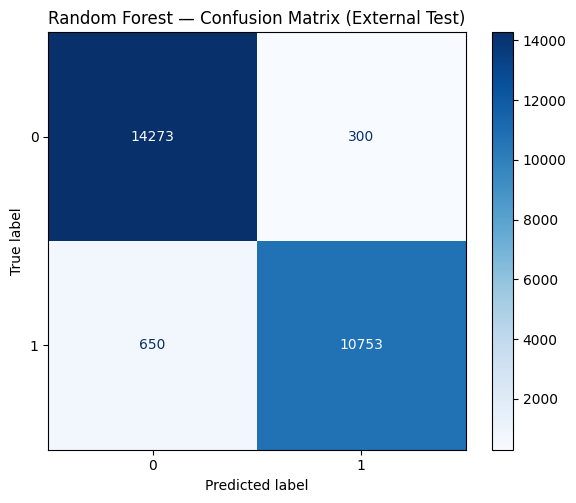

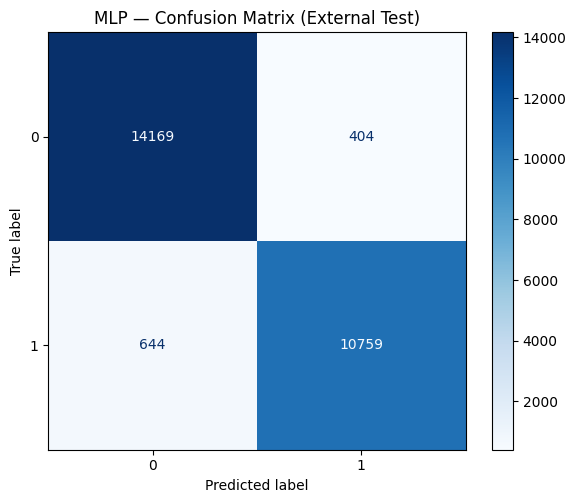

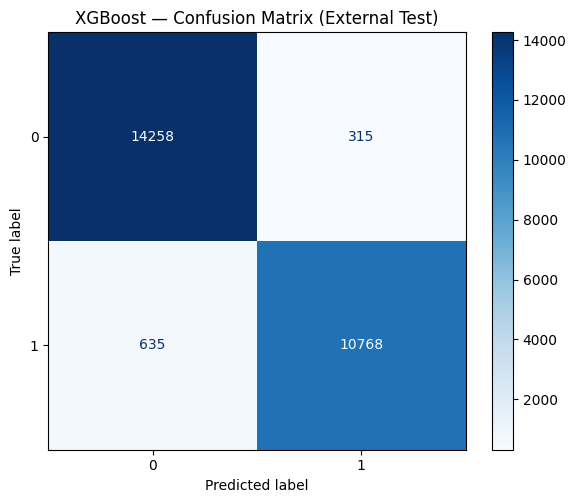

Confusion matrix dosyaları kaydedildi.


In [12]:
# ============================================================
# HÜCRE 9 — Confusion matrix (Baseline, external test)
# ============================================================
if X_external is not None and trained_models:
    for model_name, model in trained_models.items():
        y_pred = model.predict(X_external)
        fig, ax = plt.subplots(figsize=(6, 5))
        ConfusionMatrixDisplay.from_predictions(
            y_external, y_pred, ax=ax, values_format="d", cmap="Blues"
        )
        ax.set_title(f"{model_name} — Confusion Matrix (External Test)")
        plt.tight_layout()
        safe_name = model_name.lower().replace(" ", "_").replace("/", "_").replace("-", "_")
        path = FIGURES_DIR / f"confusion_matrix_{safe_name}_external.png"
        plt.savefig(path, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close(fig)
    print("Confusion matrix dosyaları kaydedildi.")
else:
    print("External test yok, confusion matrix oluşturulmadı.")


---
## Bölüm 2 — SHAP Tabanlı Öznitelik Seçimi

**Yenilik:** Literatürde SHAP yalnızca açıklanabilirlik amacıyla kullanılmıştır.  
Bu çalışmada SHAP değerleri **bir öznitelik seçim mekanizması** olarak uygulanmaktadır:  
XGBoost ve Random Forest modellerinden elde edilen normalize SHAP skorları birleştirilerek  
model-agnostik, matematiksel garantili bir öznitelik sıralaması oluşturulmaktadır.

| Çalışma | Yöntem |
|---|---|
| Jiang et al. (2022) | RF-RFE (22→17 öznitelik) |
| Islam et al. (2023) | GridSearch + 3 farklı reduction |
| **Bu çalışma** | **SHAP tabanlı öznitelik seçimi (ilk kez)** |


In [13]:
# ============================================================
# HÜCRE 10 — Preprocessor'ı SHAP için ayrıca fit et
# Pipeline içinde gizli kaldığı için dönüştürülmüş
# uzayda SHAP hesaplayabilmek üzere ayrıca fit edilir.
# ============================================================
try:
    ohe_shap = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe_shap = OneHotEncoder(handle_unknown="ignore", sparse=False)

shap_preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", ohe_shap, categorical_features),
])

X_proc = shap_preprocessor.fit_transform(X)

ohe_fitted        = shap_preprocessor.named_transformers_["cat"]
cat_feature_names = ohe_fitted.get_feature_names_out(categorical_features).tolist()
all_feature_names = numeric_features + cat_feature_names

print(f"Dönüştürülmüş X boyutu      : {X_proc.shape}")
print(f"OHE sonrası öznitelik sayısı: {len(all_feature_names)}")


Dönüştürülmüş X boyutu      : (103904, 27)
OHE sonrası öznitelik sayısı: 27


In [14]:
# ============================================================
# HÜCRE 11 — XGBoost ve RF'i tam veri üzerinde eğit (SHAP için)
# ============================================================
print("XGBoost eğitiliyor...")
xgb_shap = XGBClassifier(
    n_estimators=100, random_state=42,
    eval_metric="logloss", verbosity=0, n_jobs=-1
)
xgb_shap.fit(X_proc, y)
print("  ✓ XGBoost hazır")

print("Random Forest eğitiliyor...")
rf_shap = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_shap.fit(X_proc, y)
print("  ✓ Random Forest hazır")


XGBoost eğitiliyor...
  ✓ XGBoost hazır
Random Forest eğitiliyor...
  ✓ Random Forest hazır


In [15]:
# ============================================================
# HÜCRE 12 — SHAP değerlerini hesapla (2000 gözlem örneklem)
# ============================================================
np.random.seed(42)
sample_idx    = np.random.choice(len(X_proc), size=2000, replace=False)
X_shap_sample = X_proc[sample_idx]

# XGBoost SHAP
print("SHAP hesaplanıyor: XGBoost...")
exp_xgb    = shap.TreeExplainer(xgb_shap)
sv_xgb_raw = exp_xgb.shap_values(X_shap_sample)   # (n, d)
sv_xgb     = np.abs(sv_xgb_raw).mean(axis=0)       # (d,)
print(f"  ✓ XGBoost SHAP shape: {sv_xgb.shape}")

# Random Forest SHAP
print("SHAP hesaplanıyor: Random Forest...")
exp_rf    = shap.TreeExplainer(rf_shap)
sv_rf_raw = exp_rf.shap_values(X_shap_sample)
if isinstance(sv_rf_raw, list):          # eski shap versiyonları
    sv_rf = np.abs(sv_rf_raw[1]).mean(axis=0)
elif sv_rf_raw.ndim == 3:               # (n, d, 2)
    sv_rf = np.abs(sv_rf_raw[:, :, 1]).mean(axis=0)
else:                                    # (n, d)
    sv_rf = np.abs(sv_rf_raw).mean(axis=0)
print(f"  ✓ RF SHAP shape: {sv_rf.shape}")


SHAP hesaplanıyor: XGBoost...
  ✓ XGBoost SHAP shape: (27,)
SHAP hesaplanıyor: Random Forest...
  ✓ RF SHAP shape: (27,)


In [16]:
# ============================================================
# HÜCRE 13 — Normalize, birleştir, orijinal özniteliklere topla
# ============================================================
sv_xgb_norm  = sv_xgb / sv_xgb.sum()
sv_rf_norm   = sv_rf  / sv_rf.sum()
combined_shap = (sv_xgb_norm + sv_rf_norm) / 2

def aggregate_to_original_features(shap_vals, feat_names, num_feats, cat_feats):
    """OHE alt sütunlarını orijinal kategorik özniteliğe toplar."""
    result = {}
    for feat in num_feats:
        result[feat] = shap_vals[feat_names.index(feat)]
    for cat in cat_feats:
        idxs = [i for i, fn in enumerate(feat_names) if fn.startswith(cat + "_")]
        result[cat] = shap_vals[idxs].sum()
    return result

orig_importance = aggregate_to_original_features(
    combined_shap, all_feature_names, numeric_features, categorical_features
)

shap_df = (
    pd.DataFrame.from_dict(orig_importance, orient="index", columns=["combined_shap"])
    .sort_values("combined_shap", ascending=False)
)
shap_df["cumulative_pct"] = (
    shap_df["combined_shap"].cumsum() / shap_df["combined_shap"].sum() * 100
).round(2)

print("SHAP tabanlı öznitelik önem sıralaması:")
display(shap_df)
shap_df.to_csv(TABLES_DIR / "shap_feature_importance.csv")


SHAP tabanlı öznitelik önem sıralaması:


,combined_shap,cumulative_pct
Inflight wifi service,0.193702,19.37
Type of Travel,0.183954,37.77
Online boarding,0.112152,48.98
Customer Type,0.088078,57.79
Class,0.072191,65.01
Inflight entertainment,0.035440,68.55
Baggage handling,0.032821,71.83
Seat comfort,0.029789,74.81
Inflight service,0.029547,77.77
Checkin service,0.028746,80.64


In [17]:
# ============================================================
# HÜCRE 14 — Öznitelik seçimi: Kümülatif %90 eşiği
# ============================================================
CUMULATIVE_THRESHOLD = 90   # 85 veya 95 ile de denenebilir

selected_features = []
for feat, row in shap_df.iterrows():
    selected_features.append(feat)
    if row["cumulative_pct"] >= CUMULATIVE_THRESHOLD:
        break

eliminated_features = [f for f in shap_df.index if f not in selected_features]

print(f"Eşik                     : kümülatif %{CUMULATIVE_THRESHOLD}")
print(f"Seçilen öznitelik sayısı : {len(selected_features)} / {len(shap_df)}")
print(f"Seçilen  : {selected_features}")
print(f"Elenen   : {eliminated_features}")


Eşik                     : kümülatif %90
Seçilen öznitelik sayısı : 14 / 22
Seçilen  : ['Inflight wifi service', 'Type of Travel', 'Online boarding', 'Customer Type', 'Class', 'Inflight entertainment', 'Baggage handling', 'Seat comfort', 'Inflight service', 'Checkin service', 'Leg room service', 'Ease of Online booking', 'Cleanliness', 'On-board service']
Elenen   : ['Gate location', 'Age', 'Arrival Delay in Minutes', 'Flight Distance', 'Departure/Arrival time convenient', 'Food and drink', 'Departure Delay in Minutes', 'Gender']


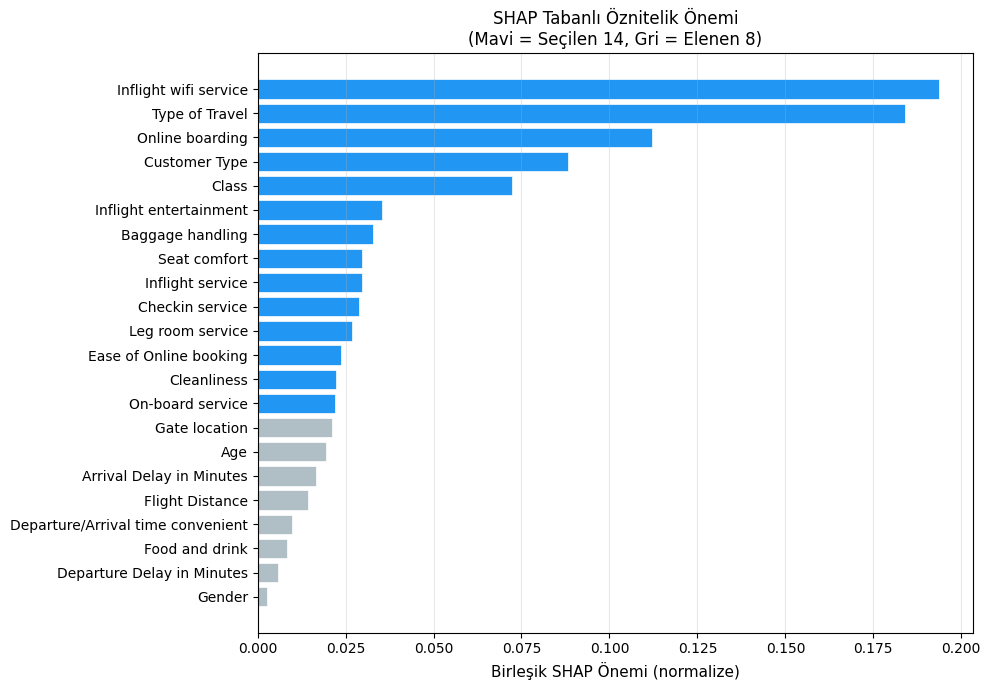

Görsel kaydedildi.


In [18]:
# ============================================================
# HÜCRE 15 — Görsel 1: Öznitelik önem bar chart
# ============================================================
fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#2196F3" if f in selected_features else "#B0BEC5" for f in shap_df.index]
ax.barh(
    shap_df.index[::-1], shap_df["combined_shap"].values[::-1],
    color=colors[::-1], edgecolor="white", linewidth=0.5
)
ax.set_xlabel("Birleşik SHAP Önemi (normalize)", fontsize=11)
ax.set_title(
    f"SHAP Tabanlı Öznitelik Önemi\n"
    f"(Mavi = Seçilen {len(selected_features)}, Gri = Elenen {len(eliminated_features)})",
    fontsize=12
)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "shap_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()
print("Görsel kaydedildi.")


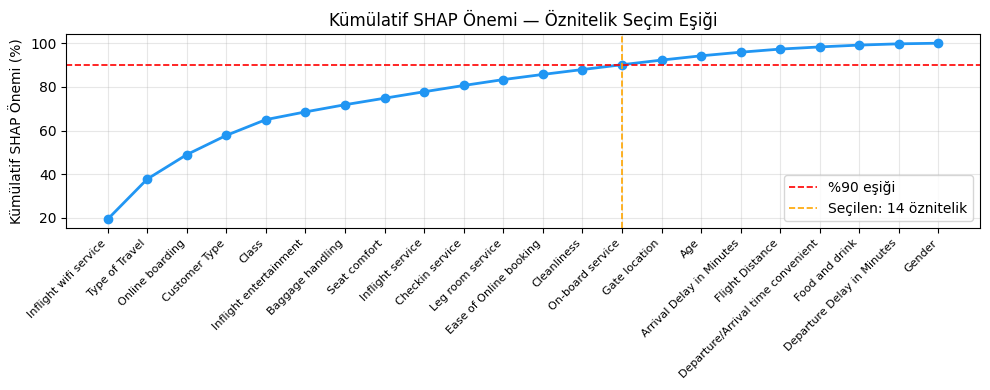

Görsel kaydedildi.


In [19]:
# ============================================================
# HÜCRE 16 — Görsel 2: Kümülatif eğri
# ============================================================
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(shap_df)+1), shap_df["cumulative_pct"].values,
        marker="o", color="#2196F3", linewidth=2, markersize=6)
ax.axhline(CUMULATIVE_THRESHOLD, color="red", linestyle="--", linewidth=1.2,
           label=f"%{CUMULATIVE_THRESHOLD} eşiği")
ax.axvline(len(selected_features), color="orange", linestyle="--", linewidth=1.2,
           label=f"Seçilen: {len(selected_features)} öznitelik")
ax.set_xticks(range(1, len(shap_df)+1))
ax.set_xticklabels(shap_df.index, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Kümülatif SHAP Önemi (%)")
ax.set_title("Kümülatif SHAP Önemi — Öznitelik Seçim Eşiği")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "shap_cumulative_curve.png", dpi=300, bbox_inches="tight")
plt.show()
print("Görsel kaydedildi.")


In [20]:
# ============================================================
# HÜCRE 17 — SHAP seçimi sonrası preprocessor ve X alt kümesi
# ============================================================
sel_categorical = [f for f in categorical_features if f in selected_features]
sel_numeric     = [f for f in numeric_features     if f in selected_features]

print(f"Seçilen kategorik : {sel_categorical}")
print(f"Seçilen sayısal   : {sel_numeric}")

if sel_categorical:
    sel_preprocessor_sparse = ColumnTransformer([
        ("num", StandardScaler(), sel_numeric),
        ("cat", make_ohe(dense=False), sel_categorical),
    ])
    sel_preprocessor_dense = ColumnTransformer([
        ("num", StandardScaler(), sel_numeric),
        ("cat", make_ohe(dense=True), sel_categorical),
    ])
else:
    sel_preprocessor_sparse = ColumnTransformer([("num", StandardScaler(), sel_numeric)])
    sel_preprocessor_dense  = sel_preprocessor_sparse

X_sel = X[selected_features]
print(f"X_sel boyutu: {X_sel.shape}")

if X_external is not None:
    X_external_sel = X_external[selected_features]
    print(f"X_external_sel boyutu: {X_external_sel.shape}")
else:
    X_external_sel = None


Seçilen kategorik : ['Customer Type', 'Type of Travel', 'Class']
Seçilen sayısal   : ['Inflight wifi service', 'Ease of Online booking', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness']
X_sel boyutu: (103904, 14)
X_external_sel boyutu: (25976, 14)


In [21]:
# ============================================================
# HÜCRE 18 — Model tanımları (SHAP seçimi sonrası)
# ============================================================
models_sel = {
    "kNN": Pipeline([
        ("preprocessor", sel_preprocessor_sparse),
        ("classifier", KNeighborsClassifier(n_neighbors=5))
    ]),
    "Naive Bayes": Pipeline([
        ("preprocessor", sel_preprocessor_dense),
        ("classifier", GaussianNB())
    ]),
    "Logistic Regression": Pipeline([
        ("preprocessor", sel_preprocessor_sparse),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "LSVM": Pipeline([
        ("preprocessor", sel_preprocessor_sparse),
        ("classifier", LinearSVC(random_state=42, max_iter=5000))
    ]),
    "RBF SVM": Pipeline([
        ("preprocessor", sel_preprocessor_sparse),
        ("classifier", SVC(kernel="rbf", random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", sel_preprocessor_sparse),
        ("classifier", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
    ]),
    "MLP": Pipeline([
        ("preprocessor", sel_preprocessor_sparse),
        ("classifier", MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42))
    ]),
    "XGBoost": Pipeline([
        ("preprocessor", sel_preprocessor_sparse),
        ("classifier", XGBClassifier(
            n_estimators=100, random_state=42,
            eval_metric="logloss", verbosity=0, n_jobs=-1
        ))
    ]),
}
print("Tanımlı modeller (SHAP seçimi):", list(models_sel.keys()))


Tanımlı modeller (SHAP seçimi): ['kNN', 'Naive Bayes', 'Logistic Regression', 'LSVM', 'RBF SVM', 'Random Forest', 'MLP', 'XGBoost']


In [22]:
# ============================================================
# HÜCRE 19 — 5-Katlı CV (SHAP seçimi sonrası)
# ============================================================
fold_results_sel = []
cv_summary_sel   = []

for model_name, model in models_sel.items():
    print(f"===== {model_name} (SHAP seçimi) =====")
    scores = cross_validate(
        model, X_sel, y, cv=cv, scoring=scoring,
        n_jobs=1, return_train_score=False, error_score="raise"
    )
    for i in range(5):
        fold_results_sel.append({
            "Model": model_name, "Fold": i + 1,
            "Accuracy":    scores["test_accuracy"][i],
            "Precision":   scores["test_precision"][i],
            "Recall":      scores["test_recall"][i],
            "F1":          scores["test_f1"][i],
            "Specificity": scores["test_specificity"][i],
            "MCC":         scores["test_mcc"][i],
        })
    cv_summary_sel.append({
        "Model":       model_name,
        "Accuracy":    scores["test_accuracy"].mean(),
        "Precision":   scores["test_precision"].mean(),
        "Recall":      scores["test_recall"].mean(),
        "F1":          scores["test_f1"].mean(),
        "Specificity": scores["test_specificity"].mean(),
        "MCC":         scores["test_mcc"].mean(),
    })

fold_df_sel = pd.DataFrame(fold_results_sel)
cv_df_sel   = pd.DataFrame(cv_summary_sel).sort_values("Accuracy", ascending=False).reset_index(drop=True)

print("\n=== SHAP Seçimi — Ortalama CV Sonuçları ===")
display(cv_df_sel)
fold_df_sel.to_csv(TABLES_DIR / "shap_fold_results.csv", index=False)
cv_df_sel.to_csv(TABLES_DIR / "shap_cv_summary.csv", index=False)


===== kNN (SHAP seçimi) =====
===== Naive Bayes (SHAP seçimi) =====
===== Logistic Regression (SHAP seçimi) =====
===== LSVM (SHAP seçimi) =====
===== RBF SVM (SHAP seçimi) =====
===== Random Forest (SHAP seçimi) =====
===== MLP (SHAP seçimi) =====
===== XGBoost (SHAP seçimi) =====

=== SHAP Seçimi — Ortalama CV Sonuçları ===


,Model,Accuracy,Precision,Recall,F1,Specificity,MCC
0,XGBoost,0.961686,0.970993,0.939656,0.955066,0.978532,0.922066
1,MLP,0.957355,0.961988,0.938701,0.950189,0.971620,0.913145
2,Random Forest,0.956797,0.962047,0.937279,0.949499,0.971722,0.912002
3,RBF SVM,0.954650,0.962105,0.932060,0.946842,0.971925,0.907668
4,kNN,0.937972,0.956807,0.897368,0.926129,0.969021,0.874107
5,Logistic Regression,0.873277,0.867643,0.834958,0.850976,0.902580,0.741247
6,LSVM,0.872632,0.867934,0.832826,0.850004,0.903072,0.739908
7,Naive Bayes,0.855530,0.840821,0.822299,0.831435,0.880942,0.705224


In [23]:
# ============================================================
# HÜCRE 20 — Bağımsız test kümesi (SHAP seçimi)
# ============================================================
if X_external_sel is not None:
    ext_results_sel  = []
    trained_models_sel = {}
    for model_name, model in models_sel.items():
        print(f"External test: {model_name}")
        model.fit(X_sel, y)
        trained_models_sel[model_name] = model
        y_pred = model.predict(X_external_sel)
        ext_results_sel.append({
            "Model":       model_name,
            "Accuracy":    accuracy_score(y_external, y_pred),
            "Precision":   precision_score(y_external, y_pred, zero_division=0),
            "Recall":      recall_score(y_external, y_pred, zero_division=0),
            "F1":          f1_score(y_external, y_pred, zero_division=0),
            "Specificity": specificity_score(y_external, y_pred),
            "MCC":         matthews_corrcoef(y_external, y_pred),
        })
    ext_df_sel = pd.DataFrame(ext_results_sel).sort_values("Accuracy", ascending=False).reset_index(drop=True)
    print("\n=== SHAP Seçimi — Bağımsız Test Sonuçları ===")
    display(ext_df_sel)
    ext_df_sel.to_csv(TABLES_DIR / "shap_external_test_results.csv", index=False)
else:
    ext_df_sel = None
    print("test.csv bulunamadı, external test atlandı.")


External test: kNN
External test: Naive Bayes
External test: Logistic Regression
External test: LSVM
External test: RBF SVM
External test: Random Forest
External test: MLP
External test: XGBoost

=== SHAP Seçimi — Bağımsız Test Sonuçları ===


,Model,Accuracy,Precision,Recall,F1,Specificity,MCC
0,XGBoost,0.961926,0.971051,0.941331,0.955960,0.978042,0.922789
1,MLP,0.959732,0.964231,0.943261,0.953631,0.972621,0.918226
2,Random Forest,0.956999,0.960100,0.941156,0.950534,0.969395,0.912651
3,RBF SVM,0.955035,0.961493,0.935017,0.948070,0.970699,0.908712
4,kNN,0.939021,0.954037,0.904674,0.928700,0.965896,0.876440
5,Logistic Regression,0.869187,0.864360,0.832676,0.848222,0.897756,0.733750
6,LSVM,0.867840,0.864326,0.829080,0.846336,0.898168,0.730975
7,Naive Bayes,0.851170,0.839596,0.817066,0.828178,0.877856,0.697157


In [24]:
# ============================================================
# HÜCRE 21 — Karşılaştırma: Baseline vs SHAP seçimi
# ============================================================
baseline_renamed = cv_results_df[[
    "Model", "CV Accuracy Mean", "CV Precision Mean", "CV Recall Mean",
    "CV F1 Mean", "CV Specificity Mean", "CV MCC Mean"
]].rename(columns={
    "CV Accuracy Mean":    "Accuracy_Baseline",
    "CV Precision Mean":   "Precision_Baseline",
    "CV Recall Mean":      "Recall_Baseline",
    "CV F1 Mean":          "F1_Baseline",
    "CV Specificity Mean": "Specificity_Baseline",
    "CV MCC Mean":         "MCC_Baseline",
})

shap_renamed = cv_df_sel.rename(columns={
    "Accuracy":    "Accuracy_SHAP",
    "Precision":   "Precision_SHAP",
    "Recall":      "Recall_SHAP",
    "F1":          "F1_SHAP",
    "Specificity": "Specificity_SHAP",
    "MCC":         "MCC_SHAP",
})

comparison_df = pd.merge(baseline_renamed, shap_renamed, on="Model")
comparison_df["Delta_Accuracy"] = (comparison_df["Accuracy_SHAP"] - comparison_df["Accuracy_Baseline"]).round(4)
comparison_df["Delta_F1"]       = (comparison_df["F1_SHAP"]       - comparison_df["F1_Baseline"]).round(4)
comparison_df["Delta_MCC"]      = (comparison_df["MCC_SHAP"]      - comparison_df["MCC_Baseline"]).round(4)
comparison_df = comparison_df.sort_values("Accuracy_SHAP", ascending=False).reset_index(drop=True)

print(f"=== Karşılaştırma: Baseline ({len(X.columns)} öznitelik) vs SHAP ({len(selected_features)} öznitelik) ===")
display(comparison_df)
comparison_df.to_csv(TABLES_DIR / "shap_vs_baseline_comparison.csv", index=False)


=== Karşılaştırma: Baseline (22 öznitelik) vs SHAP (14 öznitelik) ===


,Model,Accuracy_Baseline,Precision_Baseline,Recall_Baseline,F1_Baseline,Specificity_Baseline,MCC_Baseline,Accuracy_SHAP,Precision_SHAP,Recall_SHAP,F1_SHAP,Specificity_SHAP,MCC_SHAP,Delta_Accuracy,Delta_F1,Delta_MCC
0,XGBoost,0.962860,0.970255,0.943209,0.956540,0.977887,0.924409,0.961686,0.970993,0.939656,0.955066,0.978532,0.922066,-0.0012,-0.0015,-0.0023
1,MLP,0.957028,0.955857,0.944564,0.950135,0.966558,0.912495,0.957355,0.961988,0.938701,0.950189,0.971620,0.913145,0.0003,0.0001,0.0006
2,Random Forest,0.962600,0.972356,0.940433,0.956124,0.979551,0.923946,0.956797,0.962047,0.937279,0.949499,0.971722,0.912002,-0.0058,-0.0066,-0.0119
3,RBF SVM,0.952523,0.957443,0.931860,0.944477,0.968325,0.903278,0.954650,0.962105,0.932060,0.946842,0.971925,0.907668,0.0021,0.0024,0.0044
4,kNN,0.927019,0.943543,0.884509,0.913069,0.959527,0.851616,0.937972,0.956807,0.897368,0.926129,0.969021,0.874107,0.0110,0.0131,0.0225
5,Logistic Regression,0.875212,0.870817,0.836091,0.853086,0.905127,0.745194,0.873277,0.867643,0.834958,0.850976,0.902580,0.741247,-0.0019,-0.0021,-0.0039
6,LSVM,0.874394,0.870951,0.833692,0.851902,0.905518,0.743499,0.872632,0.867934,0.832826,0.850004,0.903072,0.739908,-0.0018,-0.0019,-0.0036
7,Naive Bayes,0.848418,0.831499,0.815458,0.823381,0.873622,0.690766,0.855530,0.840821,0.822299,0.831435,0.880942,0.705224,0.0071,0.0081,0.0145


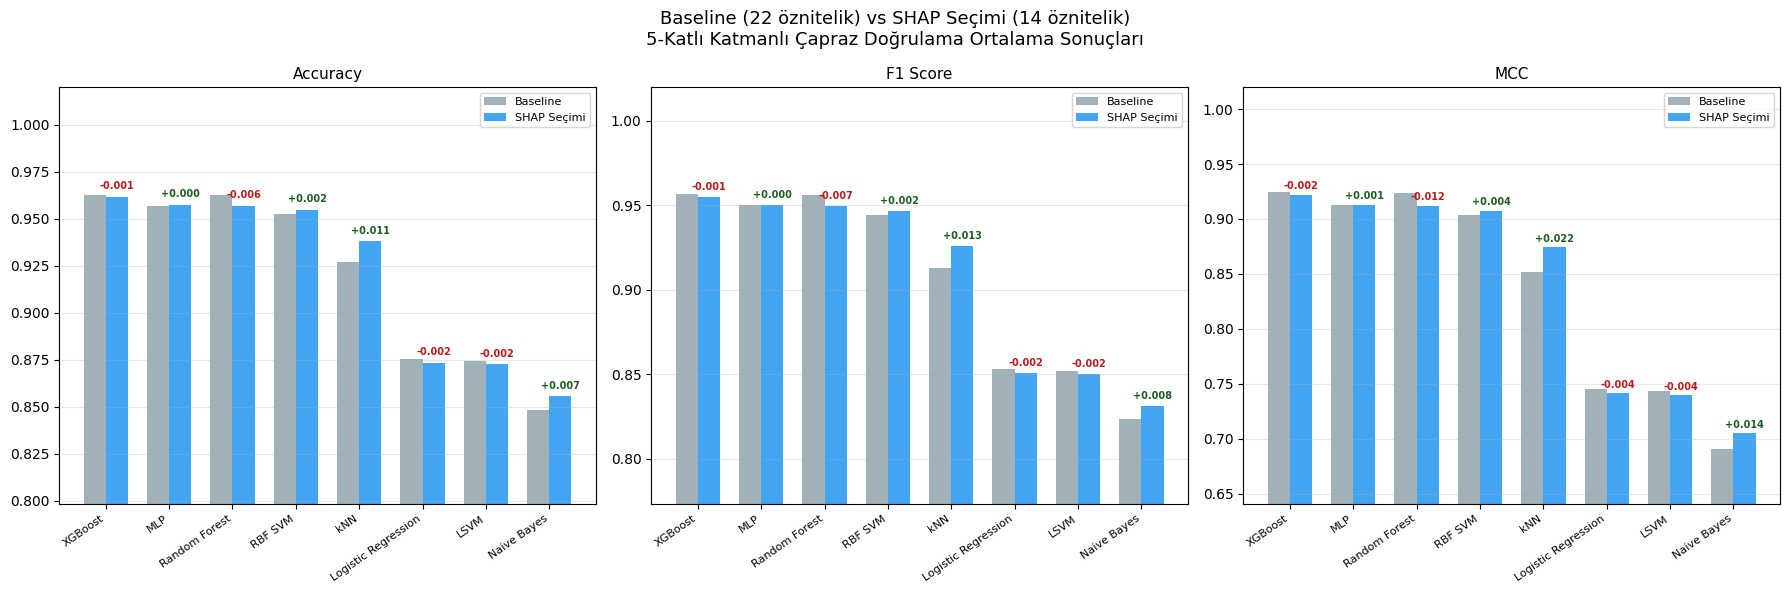

Grafik kaydedildi.


In [26]:
# ============================================================
# HÜCRE 22 — Karşılaştırma grafiği (Accuracy, F1, MCC)
# ============================================================
metrics_to_plot = [
    ("Accuracy_Baseline", "Accuracy_SHAP", "Accuracy"),
    ("F1_Baseline",       "F1_SHAP",       "F1 Score"),
    ("MCC_Baseline",      "MCC_SHAP",      "MCC"),
]
model_order = comparison_df["Model"].tolist()
x = np.arange(len(model_order))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    f"Baseline ({len(X.columns)} öznitelik) vs SHAP Seçimi ({len(selected_features)} öznitelik)\n"
    f"5-Katlı Katmanlı Çapraz Doğrulama Ortalama Sonuçları",
    fontsize=13
)

for ax, (col_base, col_shap, title) in zip(axes, metrics_to_plot):
    base_vals      = comparison_df.set_index("Model").loc[model_order, col_base].values
    shap_vals_plot = comparison_df.set_index("Model").loc[model_order, col_shap].values

    ax.bar(x - width/2, base_vals,      width, label="Baseline",     color="#90A4AE", alpha=0.85)
    ax.bar(x + width/2, shap_vals_plot, width, label="SHAP Seçimi",  color="#2196F3", alpha=0.85)
    ax.set_title(title, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(model_order, rotation=35, ha="right", fontsize=8)
    ax.set_ylim(min(base_vals.min(), shap_vals_plot.min()) - 0.05, 1.02)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    for i, (b, s) in enumerate(zip(base_vals, shap_vals_plot)):
        delta = s - b
        color = "#1B5E20" if delta >= 0 else "#B71C1C"
        ax.text(x[i] + width/2, s + 0.003, f"{delta:+.3f}",
                ha="center", va="bottom", fontsize=7, color=color, fontweight="bold")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "shap_vs_baseline_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
print("Grafik kaydedildi.")


In [27]:
# ============================================================
# HÜCRE 23 — Özet rapor (makale için)
# ============================================================
print("=" * 65)
print("SHAP TABANLI ÖZNİTELİK SEÇİMİ — ÖZET RAPOR")
print("=" * 65)
print(f"Toplam öznitelik          : {len(X.columns)}")
print(f"SHAP ile seçilen          : {len(selected_features)}")
print(f"Elenen                    : {len(eliminated_features)}")
print(f"Kümülatif eşik            : %{CUMULATIVE_THRESHOLD}")
print()
print("Seçilen öznitelikler:")
for i, f in enumerate(selected_features, 1):
    print(f"  {i:2d}. {f}  (kümülatif: %{shap_df.loc[f, 'cumulative_pct']})")
print()
print("Elenen öznitelikler:")
for f in eliminated_features:
    print(f"  -  {f}")
print()
best = comparison_df.iloc[0]
print(f"En iyi model (SHAP) : {best['Model']}")
print(f"  Accuracy : {best['Accuracy_SHAP']:.4f}  (baseline: {best['Accuracy_Baseline']:.4f}, Δ={best['Delta_Accuracy']:+.4f})")
print(f"  F1       : {best['F1_SHAP']:.4f}  (baseline: {best['F1_Baseline']:.4f}, Δ={best['Delta_F1']:+.4f})")
print(f"  MCC      : {best['MCC_SHAP']:.4f}  (baseline: {best['MCC_Baseline']:.4f}, Δ={best['Delta_MCC']:+.4f})")
print("=" * 65)


SHAP TABANLI ÖZNİTELİK SEÇİMİ — ÖZET RAPOR
Toplam öznitelik          : 22
SHAP ile seçilen          : 14
Elenen                    : 8
Kümülatif eşik            : %90

Seçilen öznitelikler:
   1. Inflight wifi service  (kümülatif: %19.37)
   2. Type of Travel  (kümülatif: %37.77)
   3. Online boarding  (kümülatif: %48.98)
   4. Customer Type  (kümülatif: %57.79)
   5. Class  (kümülatif: %65.01)
   6. Inflight entertainment  (kümülatif: %68.55)
   7. Baggage handling  (kümülatif: %71.83)
   8. Seat comfort  (kümülatif: %74.81)
   9. Inflight service  (kümülatif: %77.77)
  10. Checkin service  (kümülatif: %80.64)
  11. Leg room service  (kümülatif: %83.34)
  12. Ease of Online booking  (kümülatif: %85.7)
  13. Cleanliness  (kümülatif: %87.94)
  14. On-board service  (kümülatif: %90.15)

Elenen öznitelikler:
  -  Gate location
  -  Age
  -  Arrival Delay in Minutes
  -  Flight Distance
  -  Departure/Arrival time convenient
  -  Food and drink
  -  Departure Delay in Minutes
  -  Gender

